In [1]:
# import dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
## reading the dataset 50 startups

from google.colab import files
files.upload()


Saving 50_Startups.csv to 50_Startups.csv


{'50_Startups.csv': b'R&D Spend,Administration,Marketing Spend,State,Profit\r\n165349.2,136897.8,471784.1,New York,192261.83\r\n162597.7,151377.59,443898.53,California,191792.06\r\n153441.51,101145.55,407934.54,Florida,191050.39\r\n144372.41,118671.85,383199.62,New York,182901.99\r\n142107.34,91391.77,366168.42,Florida,166187.94\r\n131876.9,99814.71,362861.36,New York,156991.12\r\n134615.46,147198.87,127716.82,California,156122.51\r\n130298.13,145530.06,323876.68,Florida,155752.6\r\n120542.52,148718.95,311613.29,New York,152211.77\r\n123334.88,108679.17,304981.62,California,149759.96\r\n101913.08,110594.11,229160.95,Florida,146121.95\r\n100671.96,91790.61,249744.55,California,144259.4\r\n93863.75,127320.38,249839.44,Florida,141585.52\r\n91992.39,135495.07,252664.93,California,134307.35\r\n119943.24,156547.42,256512.92,Florida,132602.65\r\n114523.61,122616.84,261776.23,New York,129917.04\r\n78013.11,121597.55,264346.06,California,126992.93\r\n94657.16,145077.58,282574.31,New York,125370

In [6]:
dataset = pd.read_csv('50_Startups.csv')

In [7]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [8]:
dataset.State.value_counts()

,count
State,
New York,17
California,17
Florida,16


In [9]:
dataset.isna().sum()

,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [11]:
# check duplicates
dataset.duplicated().sum()

np.int64(0)

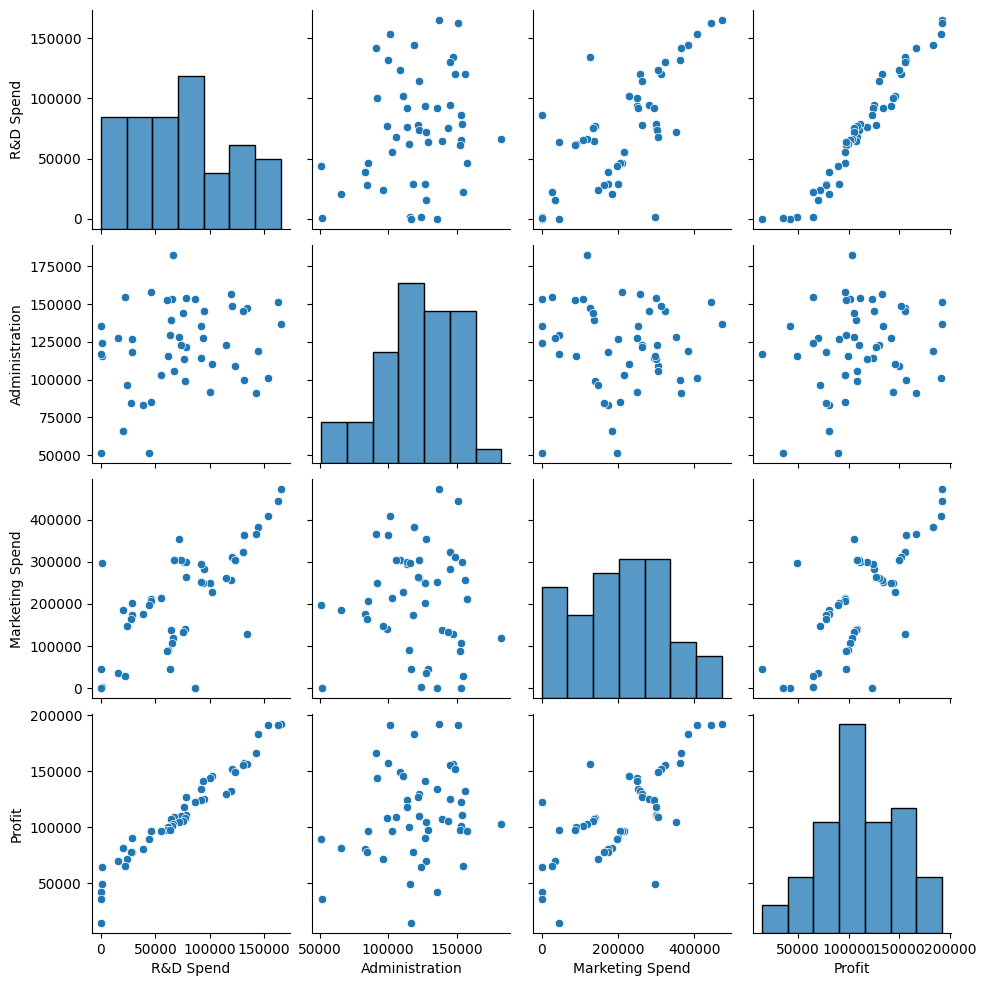

In [12]:
# EDA
sns.pairplot(dataset)

In [14]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [15]:
numeric_variables =['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
dataset[numeric_variables].corr()

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


In [17]:
# descriptive statistics
dataset.describe(include = "all")

,R&D Spend,Administration,Marketing Spend,State,Profit
count,50.000000,50.000000,50.000000,50,50.000000
unique,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,New York,NaN
freq,NaN,NaN,NaN,17,NaN
mean,73721.615600,121344.639600,211025.097800,NaN,112012.639200
std,45902.256482,28017.802755,122290.310726,NaN,40306.180338
min,0.000000,51283.140000,0.000000,NaN,14681.400000
25%,39936.370000,103730.875000,129300.132500,NaN,90138.902500
50%,73051.080000,122699.795000,212716.240000,NaN,107978.190000
75%,101602.800000,144842.180000,299469.085000,NaN,139765.977500


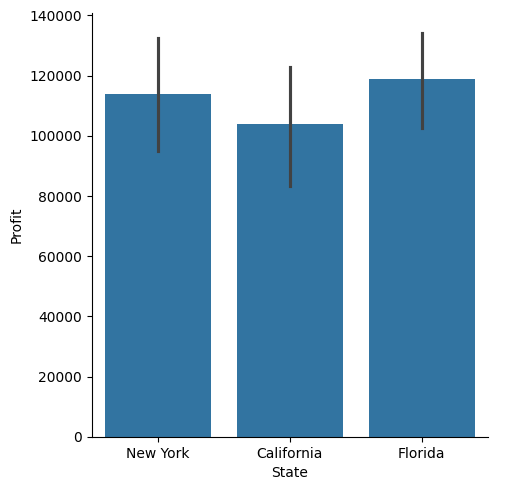

In [18]:
# distribution of Profit vs State
sns.catplot(x= "State", y = "Profit", data = dataset, kind ="bar")

R&D Spend


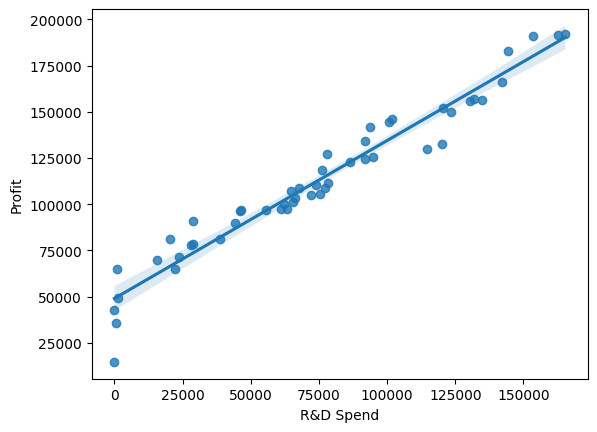

Administration


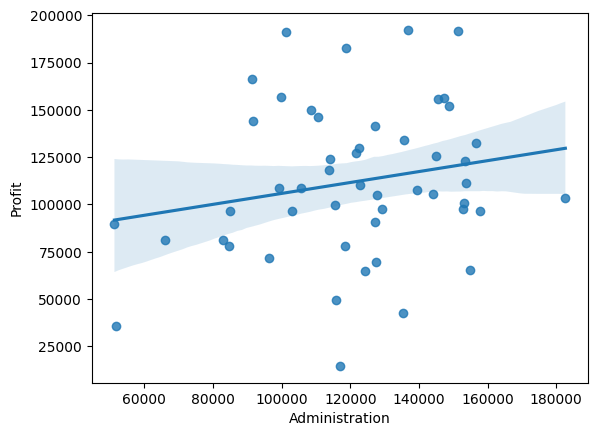

Marketing Spend


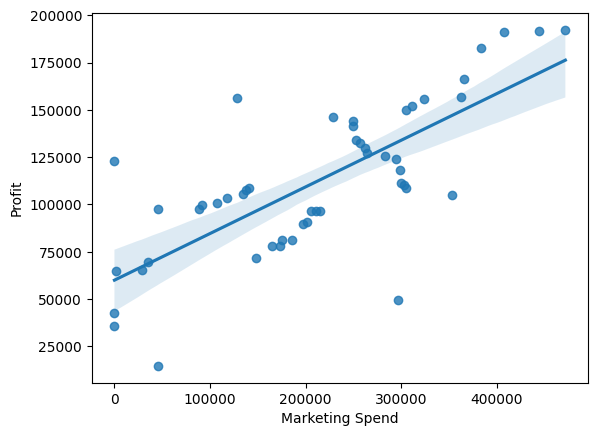

In [20]:
for column in ['R&D Spend', 'Administration', 'Marketing Spend']:
  print(column)
  sns.regplot(data= dataset, x = column, y= "Profit")
  plt.show()


In [21]:
## Modelling

## cleaned the data --> nans (nothing to do)
## EDA --> correlations, seaborn plots: there are linear unidimensional trends btw the target variables and the numeric ones
## the avg Profit is not statstitically different per state (visual confidence intervals analysis --- ANOVA)


## target: Progit
## split the dataset in two: train (where the model will learn) and the test set (where we can see how the model performs)
## preprocess the data: categorical feature needs to be encoded (dummification) and also we need to std the variable
## standardizing Z_score = (X_train - mean(X_train))/std(X_train)

##scaler.fit_transform(X_train) --> Z_score = (X_train - mean(X_train))/std(X_train)
## scaler.transform(X_test) --> (X_test - mean(X_train))/std(X_train)

## train the model on the train set
## performance train set to see if the model learned
## perfirmance on the test set to check if the model behaves well in real life / in production


In [24]:
## choosing the target variable and the explanatory features

X = dataset.iloc[:, :-1] ## what I have to feed into the model
y = dataset.iloc[:, -1] ## what I want to learn

## y = f(X) supervised learning learns the best f among a class of parametric models
## y = bo + b1 X + b2 X2 + b3 X3 + b4X4 ----> b0,b1,b2,b3, b4 are the weights of the model



In [27]:
## dummification

X = pd.get_dummies(X)
X
## in the dummification the last category disappears because we just needto know if T/F in two to infer the third one
## it is a good procedure because 3 columns would be redudant and this would carry out noise to the propagation of signal
## good practice to avoid overfitting (when the model learns too much noise on the train data)

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [31]:
X_test

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
28,66051.52,182645.56,118148.20,True,False
11,100671.96,91790.61,249744.55,False,False
10,101913.08,110594.11,229160.95,True,False
41,27892.92,84710.77,164470.71,True,False
2,153441.51,101145.55,407934.54,True,False
27,72107.60,127864.55,353183.81,False,True
38,20229.59,65947.93,185265.10,False,True
31,61136.38,152701.92,88218.23,False,True
22,73994.56,122782.75,303319.26,True,False
4,142107.34,91391.77,366168.42,True,False


In [32]:
## standardize the data

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) ## ---> mean(X_train), std(X_train) & (X_train -mean(X_train))/std(X_train)
X_test = scaler.transform(X_test) ## ---> (X_test - mean(X_test) /std(X_test))

In [33]:
X_train

array([[-0.35006454, -0.78547109,  0.1011968 ,  1.73205081, -0.73379939],
       [-0.55530319, -1.48117426,  0.02734979, -0.57735027,  1.36277029],
       [ 0.07935762,  0.80133381, -0.55152132,  1.73205081, -0.73379939],
       [-0.54638238,  1.32505817,  0.07011684, -0.57735027, -0.73379939],
       [ 0.43485371, -0.35598663,  0.75148516,  1.73205081, -0.73379939],
       [ 1.26943143,  0.85518519,  0.98603118,  1.73205081, -0.73379939],
       [ 1.04525007,  1.28077047,  0.4404    ,  1.73205081, -0.73379939],
       [-1.529843  ,  0.02942065, -1.6218751 , -0.57735027,  1.36277029],
       [-1.53976251, -2.76767264, -1.6372965 , -0.57735027,  1.36277029],
       [-0.13115188,  1.14497701, -0.76949991, -0.57735027,  1.36277029],
       [ 0.92791613, -0.02992062,  0.48303162, -0.57735027,  1.36277029],
       [-0.20932933, -0.2993768 , -0.89915412,  1.73205081, -0.73379939],
       [-0.17870828,  0.2251352 , -1.26401642, -0.57735027, -0.73379939],
       [ 0.1374709 , -0.06929437,  0.5

In [34]:
## create the linear Regression with sklearb

from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train) ## fit the train data to make the model learn

LinearRegression()

In [36]:
## y = bo + b1X1 + b2X2 + b3 X3 + b4X4 + b5X5

regressor.coef_ ## b1,b2,b3,b4,b5
regressor.intercept_ ## bo which is the bias


np.float64(109446.44725)

In [37]:
## mean square error, r2 score

from sklearn.metrics import mean_squared_error, r2_score
y_pred_test = regressor.predict(X_test)
y_pred_train = regressor.predict(X_train)

## performances: MSE

print("MSE train: ", mean_squared_error(y_train, y_pred_train))
print("MSE test: ", mean_squared_error(y_test, y_pred_test))

## the model makes more errors on the test set


MSE train:  81571001.8007737
MSE test:  83502864.03257772


In [38]:
print("r2 score on the train set:", r2_score(y_train, y_pred_train))
print("r2 score on the test set:", r2_score(y_test, y_pred_test))

r2 score on the train set: 0.9501847627493607
r2 score on the test set: 0.9347068473282423


In [ ]:
## the linear regression was a great model: it performs very well on the train set
## also it generalizes well
## there is a slight overfitting because the performance degrades just a bit on the test set